In [1]:
import cobra
import pickle
import pycomo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pycomo.configure_logger(level="error")

2026-09-15 16:26:14,361 - PyCoMo - INFO - Logger initialized.


In [2]:
with open("../run_metadata.pkl", "rb") as f:
    run_metadata = pickle.load(f)

FIXED_UPTAKE = run_metadata["fixed_uptake"]

In [3]:
common_uptakes = ['so4', 'pi', 'mg2', 'k', 'ca2', 'h', 'h2', 'h2o']

dimes = {"Rhodoferax": {
            "mEmC_1": {"uptakes": ["nh4", "fe2", "fum", "o2"],
                        "secretion": ["mal_L",  "co2"]},
            "mEmC_3": {"uptakes": ["nh4", "fe2", "fum", "o2"],
                        "secretion": ["mal_L",  "co2"]},
    
            "mEmC_2": {"uptakes": ["nh4", "fe2", "cit", "o2"],
                    "secretion": ["mal_L",  "co2"]},
            "mEmC_4": {"uptakes": ["nh4", "fe2", "cit", "o2"],
                    "secretion": ["mal_L",  "co2"]},
            # "mEmC_5": {"uptakes": ["nh4", "fe2", "mal_L", "o2"],
            #         "secretion": ["co2"]},
            # "mEmC_6": {"uptakes": ["nh4", "fe2", "mal_L", "o2", "co2"],
            #           "secretion": []},
            "mE_1": {"uptakes": ["nh4", "ac", "fe3", "o2"],
                    "secretion": ["co2"]},
            "mU_1": {"uptakes": ["nh4", "ac", "fe3", "o2"],
                    "secretion": ["co2"]},
},
        "Geobacter": {
            "mEmC_1": {"uptakes": ["nh4", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_2": {"uptakes": ["nh4", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_3": {"uptakes": ["n2", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            "mEmC_4": {"uptakes": ["n2", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            # "mEmC_5": {"uptakes": ["n2", "fe3", "cit"],
            #           "secretion": ["fe2", "mal_L", "co2", "h2s"]},
            # "mEmC_6": {"uptakes": ["n2", "fe3", "cit"],
            #           "secretion": ["fe2", "mal_L", "co2", "h2s"]},
            "mE_1": {"uptakes": ["n2", "fe3", "mal_L"],
                  "secretion": ["fe2", "ac", "co2", "h2s"]},
            "mU_1": {"uptakes": ["n2", "fe3", "lac_L"],
                  "secretion": ["fe2", "ac", "co2", "h2s"]},
    }}

crossfed = {"mEmC_1": ["mal_L", "fe2"],
          "mEmC_2": ["mal_L", "fe2"],
          "mEmC_3": ["mal_L", "fe2"],
          "mEmC_4": ["mal_L", "fe2"],
          # "mEmC_5": ["mal_L", "fe2"],
          # "mEmC_6": ["mal_L", "co2",  "fe2"],
          "mE_1": ["ac"],
          "mU_1": ["ac"]}

main_c_source = {"mEmC_1": {"c_source": "fum", "feeder": "Rhodoferax", 
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_2": {"c_source": "cit", "feeder": "Rhodoferax",
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_3": {"c_source": "fum", "feeder": "Rhodoferax",
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 "mEmC_4": {"c_source": "cit", "feeder": "Rhodoferax",
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 # "mEmC_5": {"c_source": "cit", "feeder": "Geobacter", 
                 #            "receiver": "Rhodoferax", "crossfed": "mal_L"},
                 # "mEmC_6": {"c_source": "cit", "feeder": "Geobacter",
                 #            "receiver": "Rhodoferax", "crossfed": "mal_L"},
                 "mE_1":   {"c_source": "mal_L", "feeder": "Geobacter",
                            "receiver": "Rhodoferax", "crossfed": "ac"},
                 "mU_1":   {"c_source": "lac_L", "feeder": "Geobacter",
                            "receiver": "Rhodoferax", "crossfed": "ac"}}


In [4]:
model_dir = "../models/xml_models"
named_models = pycomo.load_named_models_from_dir(model_dir)
single_org_models = []
for modelname, model in named_models.items():
    print(modelname, model.slim_optimize())

    single_org_model = pycomo.SingleOrganismModel(model, modelname)
    single_org_models.append(single_org_model)

Rhodoferax 41.91559360486998
Geobacter 35.65356530827638


In [5]:
def get_medium_for_pattern(pattern, dimes, 
                           c_sources, crossfed, models):
    # basic medium
    medium = {
        'EX_so4_medium': 1000.,
        'EX_pi_medium': 1000.,
        'EX_mg2_medium': 1000.,
        'EX_k_medium': 1000.,
        'EX_ca2_medium': 1000.,
        'EX_h_medium': 1000.,
        'EX_h2_medium': 1000.,
        'EX_h2o_medium': 1000.}

    for modelname in models:
        for component in dimes[modelname][pattern]["uptakes"]:
            max_uptake = 1000.
            if component in c_sources:
                max_uptake = float(FIXED_UPTAKE)
            if component in crossfed[pattern]:
                continue
    
            medium_name = f"EX_{component}_medium"
            medium[medium_name] = max_uptake
    return medium

In [6]:
def implement_dime(pattern, dimes, com_model):
    for rxn in com_model.transfer_reactions:
        for organism in ["Geobacter", "Rhodoferax"]:
            if organism in rxn.id:
                individual_uptakes = dimes[organism][pattern]["uptakes"]
    
                # allow uptakes from medium too
                if any(f"_{met}_" in rxn.id for met in common_uptakes):
                    rxn.lower_bound = -1000
                    rxn.upper_bound = 1000
                    #print(f"{rxn.id} taken up/secreted")
                elif any(f"_{met}_" in rxn.id for met in individual_uptakes):
                    rxn.lower_bound = -1000
                    rxn.upper_bound = 0
                    #print(f"{rxn.id} taken up")
                else:
                    rxn.lower_bound = 0
                    rxn.upper_bound = 1000
                    #print(f"{rxn.id} secreted")


In [7]:
def get_compositions(com_model, mus, organism="Geobacter"):
    mins = []
    maxs = []
    feasible_mus = []

    for mu in mus:
        try:
            comps = com_model.feasible_composition_range(mu)
        except Exception as e:
            print(f"Growth rate {mu} infeasible")
            break
            
        feasible_mus.append(mu)
        geo = comps.loc[comps.reaction_id == f"{organism}_fraction_reaction"]
        mins.append(geo.min_flux.item())
        maxs.append(geo.max_flux.item())

    return feasible_mus, mins, maxs

def plot_compositions(mus, mins, maxs, organism="Geobacter", title=""):
    color = "#00a797" # "#d43689"

    plt.fill_betweenx(mus, mins, maxs, alpha = 0.5, color = color)
    plt.xlabel(f"Fraction of {organism}", size=15)
    plt.ylabel("Growth rate", size=15)
    plt.title(title)
    plt.savefig(f"../figures/{title}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [8]:
community_name = "uranium_community"
com_model_orig = pycomo.CommunityModel(single_org_models, community_name)
com_model_orig.model.solver = "cplex"
com_model_orig.model.tolerance = 1e-9

In [9]:
com_model_orig.max_growth_rate(return_abundances=True, minimal_abundance=0.1)

2026-09-15 16:26:21,258 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:22,483 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:24,333 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:25,549 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:27,090 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:28,463 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:30,057 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:31,283 - PyCoMo - INFO - Logger initialized.


,reaction_id,min_flux,max_flux
0,Rhodoferax_fraction_reaction,0.000000,1.000000
1,Geobacter_fraction_reaction,0.000000,1.000000
2,community_biomass,41.915593,41.915593


In [10]:
com_model_orig.model.reactions.Geobacter_TF_co2_Geobacter_e

Reaction identifier,Geobacter_TF_co2_Geobacter_e
Name,EX_co2(e)
Memory address,0x7f58546bac50
Stoichiometry,0.01 Geobacter_TF_co2_Geobacter_e_ub + Geobacter_co2_Geobacter_e <=> 0.01 Geobacter_TF_co2_Geobacter_e_lb + co2_medium 0.01 Geobacter_TF_co2_Geobacter_e upper bound + co2 <=> 0.01 Geobacter_TF_co2_Geobacter_e lower bound + co2
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [11]:
named_models.keys()

dict_keys(['Rhodoferax', 'Geobacter'])

LB set on Rhodoferax_TF_fum_Rhodoferax_e_lb
LB set on Geobacter_TF_mal_L_Geobacter_e_lb


2026-09-15 16:26:37,941 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:39,178 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:41,072 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:42,325 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:44,173 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:45,419 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:47,248 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:48,503 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:50,293 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:51,534 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:53,367 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:54,593 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:56,406 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:57,615 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:26:59,426 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:27:00,738 - PyCoMo - INFO - Logger initialized.
2026-09-

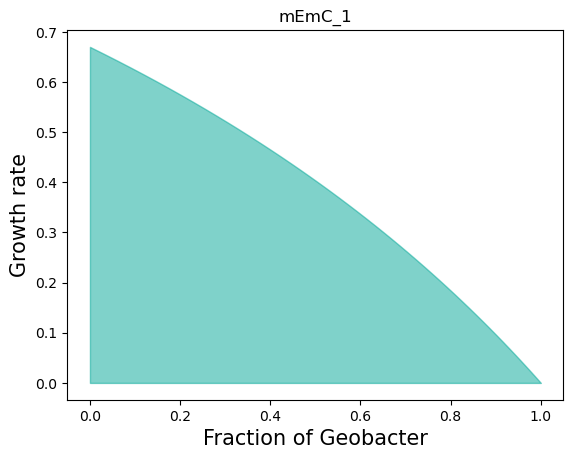

LB set on Rhodoferax_TF_cit_Rhodoferax_e_lb
LB set on Geobacter_TF_mal_L_Geobacter_e_lb


2026-09-15 16:30:00,766 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:01,982 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:03,890 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:05,187 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:07,092 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:08,361 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:10,208 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:11,431 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:13,284 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:14,498 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:16,342 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:17,890 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:19,742 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:21,076 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:22,911 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:30:24,169 - PyCoMo - INFO - Logger initialized.
2026-09-

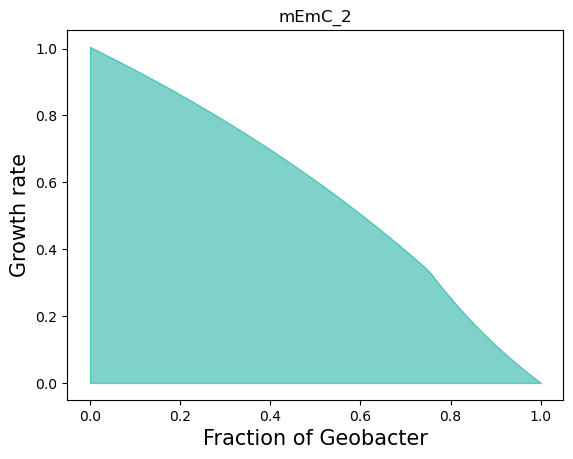

LB set on Rhodoferax_TF_fum_Rhodoferax_e_lb
LB set on Geobacter_TF_mal_L_Geobacter_e_lb


2026-09-15 16:33:23,275 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:24,524 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:26,388 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:27,613 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:29,429 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:30,637 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:32,508 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:33,769 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:35,580 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:36,832 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:38,668 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:39,887 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:41,714 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:42,926 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:44,765 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:33:46,000 - PyCoMo - INFO - Logger initialized.
2026-09-

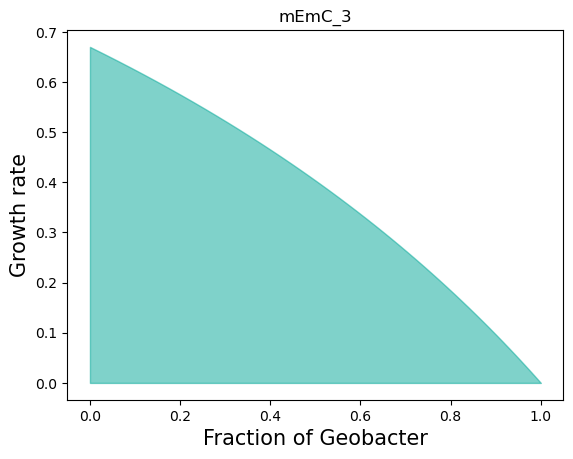

LB set on Rhodoferax_TF_cit_Rhodoferax_e_lb
LB set on Geobacter_TF_mal_L_Geobacter_e_lb


2026-09-15 16:36:45,661 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:46,887 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:48,723 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:49,967 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:51,796 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:53,006 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:54,900 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:56,137 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:57,974 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:36:59,223 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:37:01,069 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:37:02,292 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:37:03,827 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:37:05,129 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:37:06,735 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:37:08,006 - PyCoMo - INFO - Logger initialized.
2026-09-

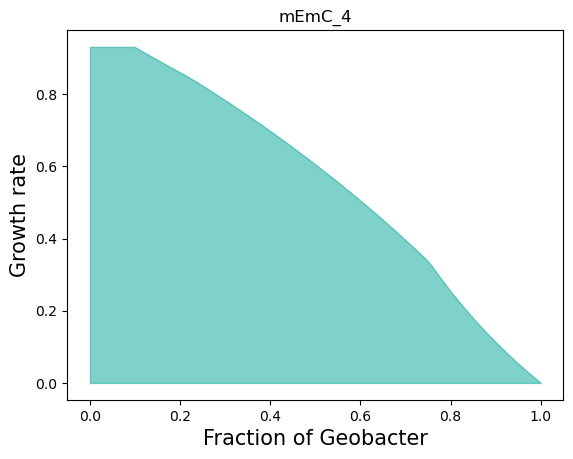

LB set on Geobacter_TF_mal_L_Geobacter_e_lb
LB set on Rhodoferax_TF_ac_Rhodoferax_e_lb


2026-09-15 16:39:31,106 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:32,315 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:34,245 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:35,561 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:37,139 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:38,381 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:40,228 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:41,468 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:43,025 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:44,288 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:46,316 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:47,533 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:49,099 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:50,348 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:51,891 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:39:53,154 - PyCoMo - INFO - Logger initialized.
2026-09-

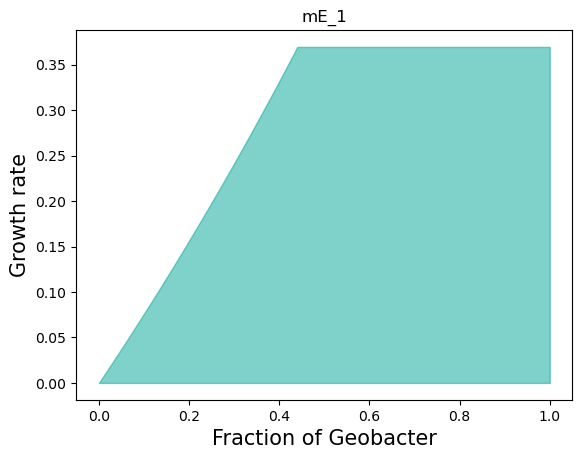

LB set on Geobacter_TF_lac_L_Geobacter_e_lb
LB set on Rhodoferax_TF_ac_Rhodoferax_e_lb


2026-09-15 16:42:11,259 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:12,521 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:14,443 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:15,689 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:17,588 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:18,832 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:20,405 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:22,103 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:23,890 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:25,122 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:26,652 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:27,895 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:29,452 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:30,692 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:32,237 - PyCoMo - INFO - Logger initialized.
2026-09-15 16:42:33,489 - PyCoMo - INFO - Logger initialized.
2026-09-

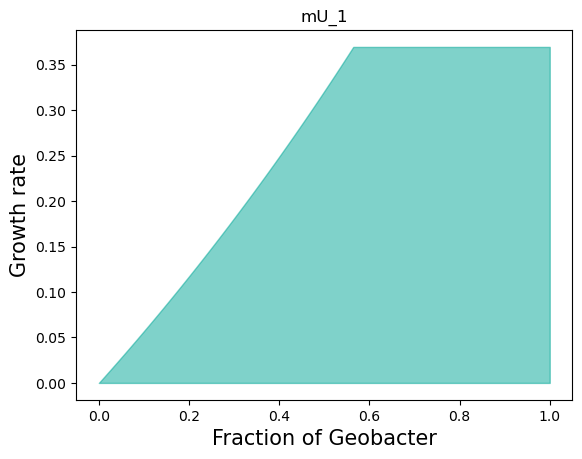

In [12]:
uptake_main = FIXED_UPTAKE/100 # scaling factor in Pycomo bounds
results = [] 
flux_results = {}

for pattern in crossfed:
    named_models = pycomo.load_named_models_from_dir(model_dir)
    single_org_models = []
    for modelname, model in named_models.items():
        single_org_model = pycomo.SingleOrganismModel(model, modelname)
        single_org_models.append(single_org_model)

    com_model = pycomo.CommunityModel(single_org_models, community_name)
    com_model.model.solver = "cplex"
    com_model.model.tolerance = 1e-9
    
    feeder = main_c_source[pattern]["feeder"]
    receiver = main_c_source[pattern]["receiver"]
    c_source = main_c_source[pattern]["c_source"]
    crossfed_c_source = main_c_source[pattern]["crossfed"]
    c_sources = [c_source, crossfed_c_source]
    
    medium = get_medium_for_pattern(pattern, dimes, 
                                    c_sources, crossfed, 
                                    named_models.keys())
    com_model.medium = medium
    com_model.apply_medium()

    implement_dime(pattern, dimes, com_model)
    
    # set uptake rate for main carbon source
    bounds_rxn = com_model.model.reactions.get_by_id(f"{feeder}_fraction_reaction")
    for met, stoich in bounds_rxn.metabolites.items():
        if (f"_{c_source}_" in met.id) and ("_lb" in met.id):
            bounds_rxn.add_metabolites({met: uptake_main}, combine=False)
            print(f"LB set on {met.id}")

        # if (pattern == "mEmC_6") and (feeder == "Geobacter"):
        #     if ("_co2_" in met.id) and ("_lb" in met.id):
        #         print(f"{met.id} forced secretion bound")
        #         bounds_rxn.add_metabolites({met: -0.077196}, combine=False)
            
    bounds_rxn2 = com_model.model.reactions.get_by_id(f"{receiver}_fraction_reaction")
    for met, stoich in bounds_rxn2.metabolites.items():
        if (f"_{crossfed_c_source}_" in met.id) and ("_lb" in met.id):
            bounds_rxn2.add_metabolites({met: uptake_main}, combine=False)
            print(f"LB set on {met.id}")
    
    fba = com_model.max_growth_rate(return_abundances=True, minimal_abundance=1e-7)
    max_mu = fba.loc[fba.reaction_id == "community_biomass"].max_flux.item()
    
    tested_mus = np.linspace(0, max_mu, 50)
    mus, mins, maxs = get_compositions(com_model, tested_mus)
    plot_compositions(mus, mins, maxs, title=pattern)

    # collect rows for this pattern
    for mu, lo, hi in zip(mus, mins, maxs):
        results.append({
            "pattern": pattern,
            "mu": mu,
            "min_fraction": lo,
            "max_fraction": hi,
        })

    # com_model.apply_fixed_growth_rate(0.32)

    # com_model.model.objective = f"{receiver}_fraction_reaction"
    # fluxes = com_model.model.optimize()
    
    # flux_results[pattern] = fluxes
    # print(fluxes.fluxes[fluxes.fluxes.index.str.endswith("_fraction_reaction")])
    
    # f = fluxes.fluxes[fluxes.fluxes.index.str.startswith("Geobacter_TF")]
    # print("Geobacter fluxes")
    # print(f[f < 0])
    # print(f[f > 0])
    # f = fluxes.fluxes[fluxes.fluxes.index.str.startswith("Rhodoferax_TF")]
    # print("Rhodoferax fluxes")
    # print(f[f < 0])
    # print(f[f > 0])
    
results_df = pd.DataFrame(results)
results_df.to_csv("../results/pycomo_composition_ranges.csv", index=False)